In [1]:
from torch_concepts.data import TrafficLights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

/home/ens36/pytorch_concepts/torch_concepts/data/traffic_construction/shared.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
n_samples = 500
dataset = TrafficLights(
	n_samples=n_samples,
	possible_starting_directions=["west"],
	resize_final_image=0.05,
	seed=0,
	selected_concepts=[
		# 'green x-axis',
		# 'green y-axis',
		'ambulance seen',
		# 'car in intersection',
		# 'other cars visible',
		'green light on selected lane',
		'car in intersection perpendicular to selected car',
		'ambulance approaching perpendicular to selected car'
	],
	split="train",
    extended_traffic_light_options=True,
)
test_dataset = TrafficLights(
	n_samples=n_samples,
	possible_starting_directions=["west"],
	resize_final_image=0.05,
	seed=0,
	selected_concepts=[
		# 'green x-axis',
		# 'green y-axis',
		'ambulance seen',
		# 'car in intersection',
		# 'other cars visible',
		'green light on selected lane',
		'car in intersection perpendicular to selected car',
		'ambulance approaching perpendicular to selected car'
	],
	split="test",
	extended_traffic_light_options=True,
)
concept_names, task_names = dataset.concept_names, dataset.task_names
n_concepts = len(concept_names)

# Make a batch dataset loader
data_loader = DataLoader(
	dataset,
	batch_size=64,
	shuffle=True,
	drop_last=False,
	num_workers=2,
)

100%|██████████| 100/100 [00:03<00:00, 31.91it/s]


  ambulance_mask: dtype=uint8, shape=(64, 64), unique=[0]
  perp_intersection_mask: dtype=uint8, shape=(64, 64, 1), unique=[0 1]


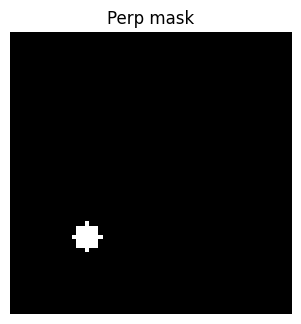

  ambulance_mask: dtype=uint8, shape=(64, 64), unique=[0]
  perp_intersection_mask: dtype=uint8, shape=(64, 64, 1), unique=[0 1]


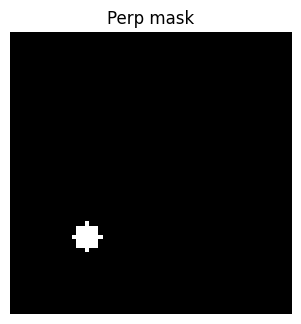

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

for i in range(2):
    sample = dataset.sample_metadata[i]
    mask = sample.get('light_mask')
    plt.subplot(1,2,2)
    plt.title('mask')
    plt.imshow(mask)
    plt.axis('off')
    plt.show()